# <b>lec02. 딥러닝 모델 -분류

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split                     

#----------------------------------------------------------------------------------- ML모델 
from sklearn.ensemble import RandomForestClassifier 
#----------------------------------------------------------------------------------  DL모델 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
#----------------------------------------------------------------------------------- 평가
from sklearn.metrics  import accuracy_score,      f1_score


import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# <B>Data Load

In [2]:
from sklearn.datasets import load_iris
X, y = load_iris(as_frame=True , return_X_y=True)
X.columns = ["sl","sw","pl","pw"]
X.head(2)

,sl,sw,pl,pw
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2


# <b> 분류 모델 점수

In [3]:
X80,X20, y80, y20 = train_test_split(X, y, test_size=0.2,random_state=4878, shuffle=True, stratify=y)
model = RandomForestClassifier(random_state=5787)
model.fit(X80, y80)
pred = model.predict(X20)

acc = accuracy_score(y20, pred)
f1  = f1_score(y20, pred, average="macro")
print(f"acc: {acc:.4f}  f1 : {f1:.4f}") 

acc: 0.9667  f1 : 0.9666


# <b> 딥러닝 모델 점수

## sparse_categorical_crossentropy
y : 0 1 2

In [4]:
model = Sequential([
    Dense(10 , activation = "relu" , input_dim=4), # ------------ input layer
    Dense(16 , activation = "relu"),               # ------------ hidden layer 3
    Dense(24 , activation = "relu"),
    Dense(8  , activation = "relu"),
    Dense(3  , activation = "softmax")                # ------------ output layer / iris는 마지막 3개 나와야함
])

In [5]:
model.compile(loss ="sparse_categorical_crossentropy", optimizer = "adam", metrics=["accuracy"]) 
# ----- l : loss o : optimizer  m : metrics <-컴파일에서 기억해야할거

In [6]:
model.summary()
# param  : AI 모델이 학습을 통해 기억해야 할 '가중치(Weight)와 편향(Bias)의 총 개수 (공식의 개수)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │              50 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 24)                  │             408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │             200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 861 (3.36 KB)

 Trainable params: 861 (3.36 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
res = model.fit(X80, y80,  epochs=50, validation_data = (X20, y20))
#res

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.3333 - loss: 1.6046 - val_accuracy: 0.3333 - val_loss: 1.5478
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3333 - loss: 1.4791 - val_accuracy: 0.3333 - val_loss: 1.4232
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3333 - loss: 1.3663 - val_accuracy: 0.3333 - val_loss: 1.3260
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3333 - loss: 1.2757 - val_accuracy: 0.3333 - val_loss: 1.2510
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3917 - loss: 1.2114 - val_accuracy: 0.6000 - val_loss: 1.1972
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5833 - loss: 1.1689 - val_accuracy: 0.6667 - val_loss: 1.1588
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6583 - loss: 1.1316 - val_accuracy: 0.6667 - val_loss: 1.1310
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6667 - loss: 1.1147 - val_accuracy: 0.6333 - val_loss: 1.1094


In [8]:
loss, acc = model.evaluate(X20, y20)
print(f"acc : {acc:.4f} , loss:{loss:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9333 - loss: 0.5385
acc : 0.9333 , loss:0.5385


In [9]:
res.history.keys()
#res.hisotry['accuracy']

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

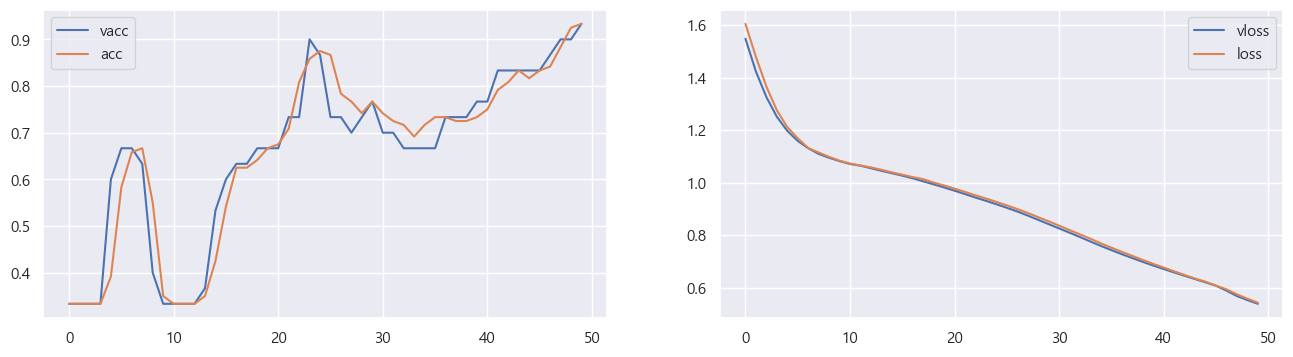

In [10]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
vacc = res.history["val_accuracy"]
acc  = res.history["accuracy"]
plt.plot(range(50), vacc , label="vacc")
plt.plot(range(50), acc  , label="acc")
plt.legend()

plt.subplot(1,2,2)
vloss = res.history["val_loss"]
loss = res.history["loss"]
plt.plot(range(50),vloss , label="vloss")
plt.plot(range(50),loss  , label="loss")
plt.legend()
plt.show()

<b> 결론 : data 갯수가 너무 작아서 ML 성능이 더 우수하게 나옴

##  <b>categorical_crossentropy
* y (원핫인코딩) : 100  010  001<br>
  정답이 숫자면 → sparse_categorical_crossentropy<br>
  정답이 원핫이면 → categorical_crossentropy
 ---------
* <b>pd.get_dummies(df)
* <b>sklearn.preprocessing.OneHotEncoder()
* <b>tensorflow.keras.utils.to_categorical()

### <b> 1. PANDAS - get_dummies
*  데이터프레임 전처리할 때 사용
*  데이터 프레임 형태 유지 & 칼럼 자동생성

In [11]:
y_encoded1 = pd.get_dummies(y, dtype=int)
y_encoded1.head(5)

,0,1,2
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0


### <b> 2. SKLEARN - OneHotEncoder
* 머신러닝 파이프라인용
* numpy배열 전환, sparse matrix기본값, train/test일관성 유지 가능

``` python
class sklearn.preprocessing.OneHotEncoder(*, categories='auto', drop=None, sparse_output=True, dtype=<class 'numpy.float64'>, handle_unknown='error', min_frequency=None, max_categories=None, feature_name_combiner='concat')

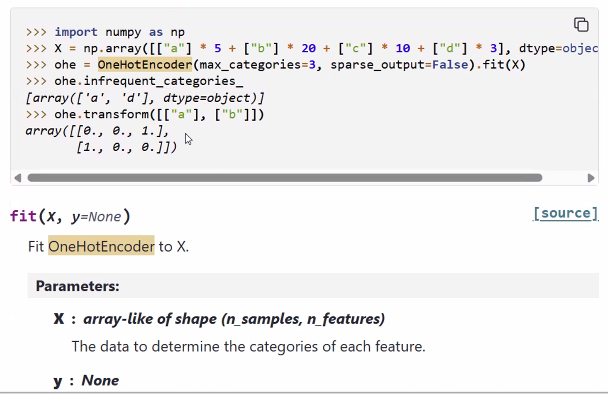

In [12]:
from sklearn.preprocessing import OneHotEncoder

In [13]:
# 1. 객체 생성 (sparse_output=False로 해야 넘파이 배열로 바로 보임)
encoder = OneHotEncoder(sparse_output = False)

# 2. 데이터를 2차원으로 변형 후 학습 및 변환
# y.values.reshape(-1, 1)은 세로 한 줄 형태로 만드는 과정입니다.
y_reshaped = np.array(y).reshape(-1, 1) # -- y를 2차로 만들기
y_encoded2 = encoder.fit_transform(y_reshaped)

print(y_encoded2[:5])

[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


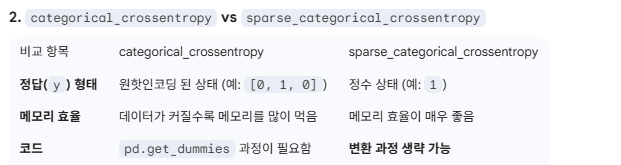

### <b> 3. TENSORFLOW - to_categorical
* 딥러닝에서 y값만 빠르게 변환할 때
* y가 0,1,2숫자일때 사용, 가장 간단

```python
tf.keras.utils.to_categorical(y, num_classes=None, dtype='float32')

In [14]:
from tensorflow.keras.utils import to_categorical

In [15]:
y_oh3 = to_categorical(y)
y_oh3[:5]

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [16]:
# y_encoded 형태로 넣어서 학습 시, y -> y_encoded로 넣어줘야함!
X80,X20, yoh80, yoh20 = train_test_split(X, y_oh3, test_size=0.2,random_state=4878, shuffle=True, stratify=y)

model = Sequential([
    Dense(units=10, activation="relu" , input_dim=4  ),   #----- input layer
    Dense(units=16, activation="relu"                ),   #----- hidden layer 3
    Dense(units=24, activation="relu"                ),    
    Dense(units=8,  activation="relu"                ),
    Dense(units=3,  activation="softmax"             )    #----- output layer   
 ])
 
#-------------------- l o m
# --------------- encoded_y 니까 sparse 지우고 "categorical_crossentropy"
model.compile(loss="categorical_crossentropy" , optimizer="adam",  metrics=["accuracy"])  


## loss="(sparce_)categorical_crossentropy" 는 오직 **군집(분류)**에서만
## **회귀**는 무조건    loss="mse"

In [17]:
res = model.fit(X80,yoh80,     epochs=50 ,   validation_data = (X20,yoh20)  )
res

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.3333 - loss: 1.4586 - val_accuracy: 0.3333 - val_loss: 1.3132
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3333 - loss: 1.2631 - val_accuracy: 0.3333 - val_loss: 1.1622
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3333 - loss: 1.1307 - val_accuracy: 0.3333 - val_loss: 1.0783
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3333 - loss: 1.0628 - val_accuracy: 0.3333 - val_loss: 1.0365
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3333 - loss: 1.0177 - val_accuracy: 0.3333 - val_loss: 1.0005
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3750 - loss: 0.9859 - val_accuracy: 0.6333 - val_loss: 0.9578
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6000 - loss: 0.9523 - val_accuracy: 0.6667 - val_loss: 0.9391
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6167 - loss: 0.9395 - val_accuracy: 0.6333 - val_loss: 0.9270


In [18]:
loss,acc = model.evaluate(X20, yoh20)
print(f"acc : {acc:.4f} , loss:{loss:.4f} " )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9333 - loss: 0.3079
acc : 0.9333 , loss:0.3079 


# <b><font color=red>모델저장

이거 너무 옛날 모델이라 최신형 아래 셀 참고 

<b> 모델 저장 - HDF5(Hierarchical Data Format version 5) 
> <big><b>.h5 확장자 - 모델, 가중치 모두 저장 가능 / Keras(TENSORFLOW)로 오픈 가능
#> ![{2DBFE858-17C8-4DCF-8C1F-8EF05EA5B0B0}.png](attachment:fa4dbab9-c5e2-4ee7-8512-ffae355faedb.png) 

* HDF5(Hierarchical Data Format version 5) 
* *.h5 : 모델저장포맷
* *.keras : 신규포맷

In [19]:
from tensorflow.keras.saving import load_model, save_model
# 모델 저장    _ [ 모델 설계도 / 학습된 가중치 / 컴파일 설정 ]이 함께 저장됨
save_model(model, "lec.02_cls_iris.keras")
print(" === 모델 저장 완료 === ")

 === 모델 저장 완료 === 


In [20]:
# 모델 불러오기
re_model = load_model("lec02_cls_iris.keras")
re_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ (None, 10)                  │              50 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 24)                  │             408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 8)                   │             200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,585 (10.10 KB)

 Trainable params: 861 (3.36 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,724 (6.74 KB)

## 레이어 이름만 출력

In [21]:
for layer in re_model.layers:
    print(layer.name)

dense_5
dense_6
dense_7
dense_8
dense_9


## 레이어 가중치 출력

In [22]:
for w in re_model.get_weights():
    print(w[:1])

[[-0.61341923  0.16271235  0.42583528  0.37324357 -0.09093189  0.45450944
   0.06686609  0.5847379   0.50531924  0.62541497]]
[0.]
[[-0.44282305  0.11089742  0.30073643  0.05351925  0.02544099 -0.10093036
   0.2520752  -0.35113776 -0.4638313  -0.33880156 -0.20935777  0.22576791
   0.22212577 -0.11128581  0.10856545  0.00732046]]
[0.00608892]
[[-0.23700352  0.4269197   0.31625658  0.42258108  0.05582636  0.39073724
   0.24061646  0.3771302   0.03099956  0.13801801 -0.01310707 -0.31833616
  -0.24718112  0.17558968  0.14328063  0.08344594  0.01919688 -0.05601457
   0.2517365  -0.15517552  0.30184722 -0.27784908  0.10079554  0.12021296]]
[0.05844528]
[[ 0.24605902  0.09403005  0.05340207 -0.19449115  0.04074242 -0.2739625
   0.42530924 -0.43837532]]
[0.08478937]
[[0.3425251  0.7939353  0.43393147]]
[-0.00368038]


# <b>가중치저장
> 범용적으로 사용하는 모델을 활용할 경우 <br>
> 확장자명 : .weights.h5

In [23]:
from tensorflow.keras.saving import load_weights, save_weights

# 1. 가중치만 따로 저장 (.weights.h5 확장자 사용)
# 모델의 설계도는 저장되지 않고, 학습된 숫자(Weight, Bias)만 저장됩니다.
save_weights(re_model, "lec.02_cls_iris.weights.h5")
print(" === 가중치 저장 완료 === ")

 === 가중치 저장 완료 === 


In [24]:
# 2. 가중치 불러오기 (중요: 변수에 대입하지 말고 모델 객체에 직접 적용)
# load_weights는 re_model의 내부 값을 직접 업데이트하며, None을 반환합니다.
save_weights(re_model,  "lec02_cls_iris.weights.h5")

In [25]:
# 3. 업데이트된 모델에서 가중치 확인하기
weights = re_model.get_weights()
print(weights)

[array([[-0.61341923,  0.16271235,  0.42583528,  0.37324357, -0.09093189,
         0.45450944,  0.06686609,  0.5847379 ,  0.50531924,  0.62541497],
       [-0.5567955 ,  0.39873862,  0.46823403, -0.5629025 , -0.476681  ,
         0.12005261,  0.5295203 ,  0.15566118,  0.16521838,  0.27071723],
       [-0.35165527,  0.12081383, -0.29278737, -0.6131176 , -0.45248726,
        -0.08799054, -0.3915843 , -0.5369626 , -0.6748711 ,  0.34510925],
       [-0.0533042 ,  0.17947505,  0.7695812 ,  0.5539298 ,  0.09009886,
        -0.18872203,  0.19096434,  0.2537588 ,  0.04034821,  0.765319  ]],
      dtype=float32), array([ 0.        , -0.07727791,  0.10146065,  0.        ,  0.        ,
        0.05696016,  0.14374687,  0.10759793,  0.04636819, -0.02245534],
      dtype=float32), array([[-0.44282305,  0.11089742,  0.30073643,  0.05351925,  0.02544099,
        -0.10093036,  0.2520752 , -0.35113776, -0.4638313 , -0.33880156,
        -0.20935777,  0.22576791,  0.22212577, -0.11128581,  0.10856545,
  

In [26]:
load_weights(re_model, "lec02_cls_iris.weights.h5")
re_model.get_weights()[:1]

[array([[-0.61341923,  0.16271235,  0.42583528,  0.37324357, -0.09093189,
          0.45450944,  0.06686609,  0.5847379 ,  0.50531924,  0.62541497],
        [-0.5567955 ,  0.39873862,  0.46823403, -0.5629025 , -0.476681  ,
          0.12005261,  0.5295203 ,  0.15566118,  0.16521838,  0.27071723],
        [-0.35165527,  0.12081383, -0.29278737, -0.6131176 , -0.45248726,
         -0.08799054, -0.3915843 , -0.5369626 , -0.6748711 ,  0.34510925],
        [-0.0533042 ,  0.17947505,  0.7695812 ,  0.5539298 ,  0.09009886,
         -0.18872203,  0.19096434,  0.2537588 ,  0.04034821,  0.765319  ]],
       dtype=float32)]